In [1]:
import sys

# xgboost must be importable for joblib to unpickle the saved XGBClassifier
!{sys.executable} -m pip install xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    fbeta_score,
)
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [3]:
RANDOM_STATE = 42

PROCESSED = Path("data/processed")   # outputs of 02_preprocessing
MODELS_DIR = Path("models")          # outputs of 03_modeling
REPORTS_DIR = Path("reports")        # evaluation artifacts written by this notebook
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "SeriousDlqin2yrs"

## 1. Load the frozen test set and the tuned models

The test split was carved out in `02_preprocessing` **before** any cleaning rule,
imputation median or winsorisation cap was learned, and has not been seen since. Loading
it here, in the evaluation notebook, is the **only** time the project touches it — this is
what makes the numbers below an honest estimate of generalisation rather than an
optimistic in-sample echo.

We load the four tuned models exactly as `03_modeling` serialised them. The labels were
saved with `index=False`, so we squeeze the single column back into a `Series`.

In [4]:
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze("columns").astype(int)

print(f"Test set: {X_test.shape}")
print(f"Test positive rate: {y_test.mean():.4f}")

models = {
    "Logistic Regression": joblib.load(MODELS_DIR / "logistic_regression.joblib"),
    "Decision Tree":       joblib.load(MODELS_DIR / "decision_tree.joblib"),
    "Random Forest":       joblib.load(MODELS_DIR / "random_forest.joblib"),
    "XGBoost":             joblib.load(MODELS_DIR / "xgboost.joblib"),
}
cv_summary = pd.read_csv(MODELS_DIR / "cv_summary.csv")
print(f"Loaded {len(models)} tuned models")

Test set: (30000, 12)
Test positive rate: 0.0668
Loaded 4 tuned models


## 2. Score the test set once

Every metric below is a function of the predicted **probability of default**
$\hat{p} = P(y=1 \mid \mathbf{x})$, not of a hard 0/1 label. We therefore call
`predict_proba` once per model and reuse the resulting probability vectors throughout —
both to avoid recomputation and to guarantee that the curves, thresholds and cost
analysis all describe the *same* predictions.

In [5]:
# Column 1 of predict_proba is P(class = 1) = P(default)
proba = {name: model.predict_proba(X_test)[:, 1] for name, model in models.items()}

## 3. Discrimination metrics — how well does the model rank risk?

Before fixing any threshold we ask a threshold-free question: does the model assign
higher default probabilities to actual defaulters than to non-defaulters? Three metrics
answer this.

### 3.1 ROC-AUC and the Gini coefficient

The ROC curve plots the true-positive rate against the false-positive rate as the
threshold sweeps from 1 to 0:

$$
\text{TPR} = \frac{TP}{TP + FN}, \qquad \text{FPR} = \frac{FP}{FP + TN}.
$$

The **area under it (AUC)** has a clean probabilistic meaning: it is the probability that
the model scores a randomly chosen defaulter above a randomly chosen non-defaulter,

$$
\text{AUC} = P\big(\hat{p}(X^{+}) > \hat{p}(X^{-})\big),
$$

so $0.5$ is random guessing and $1.0$ is perfect ranking. In credit scoring AUC is
usually reported as the **Gini coefficient**, a linear rescaling onto $[0, 1]$:

$$
\text{Gini} = 2\,\text{AUC} - 1.
$$

### 3.2 Precision–Recall AUC (average precision)

Under a ~6.7% default rate, ROC-AUC can look flattering: the FPR denominator
$FP + TN$ is dominated by the huge negative class, so even many false alarms barely move
the FPR. The **precision–recall curve** focuses on the positive class and ignores the
true negatives entirely:

$$
\text{Precision} = \frac{TP}{TP + FP}.
$$

Its summary, **average precision**, is the precision averaged over the achieved recall
levels,

$$
\text{AP} = \sum_n (R_n - R_{n-1})\, P_n,
$$

and its no-skill baseline is the prevalence (≈ 0.067), not 0.5 — a much more honest bar
under imbalance.

### 3.3 Kolmogorov–Smirnov (KS) statistic

The industry-standard **KS statistic** is the largest vertical gap between the
cumulative score distributions of the two classes,

$$
\text{KS} = \max_{s}\,\big|F_{0}(s) - F_{1}(s)\big| = \max_{t}\big(\text{TPR}(t) - \text{FPR}(t)\big),
$$

i.e. the single threshold at which good and bad clients are best separated. The second
equality is why we can read KS straight off the ROC curve.

In [6]:
def ks_statistic(y_true, y_score):
    """KS = max_t (TPR - FPR): the largest separation between the cumulative
    score distributions of the two classes."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(tpr - fpr))

rows = []
for name, p in proba.items():
    auc = roc_auc_score(y_test, p)
    rows.append({
        "model": name,
        "ROC_AUC": auc,
        "Gini": 2 * auc - 1,
        "PR_AUC": average_precision_score(y_test, p),
        "KS": ks_statistic(y_test, p),
    })

test_metrics = (
    pd.DataFrame(rows)
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)
test_metrics

,model,ROC_AUC,Gini,PR_AUC,KS
0,XGBoost,0.8686,0.7371,0.3995,0.5804
1,Random Forest,0.8662,0.7323,0.3903,0.5763
2,Logistic Regression,0.8587,0.7174,0.3849,0.5597
3,Decision Tree,0.8572,0.7144,0.3624,0.5735


## 4. ROC and Precision–Recall curves

The single numbers above compress an entire curve into a scalar. The curves themselves
show *where* each model wins. On the **ROC** plot, higher and further to the top-left is
better, and the diagonal is random guessing. On the **PR** plot, higher is better and the
dashed line marks the prevalence baseline — anything above it is genuine skill at finding
the rare defaulters.

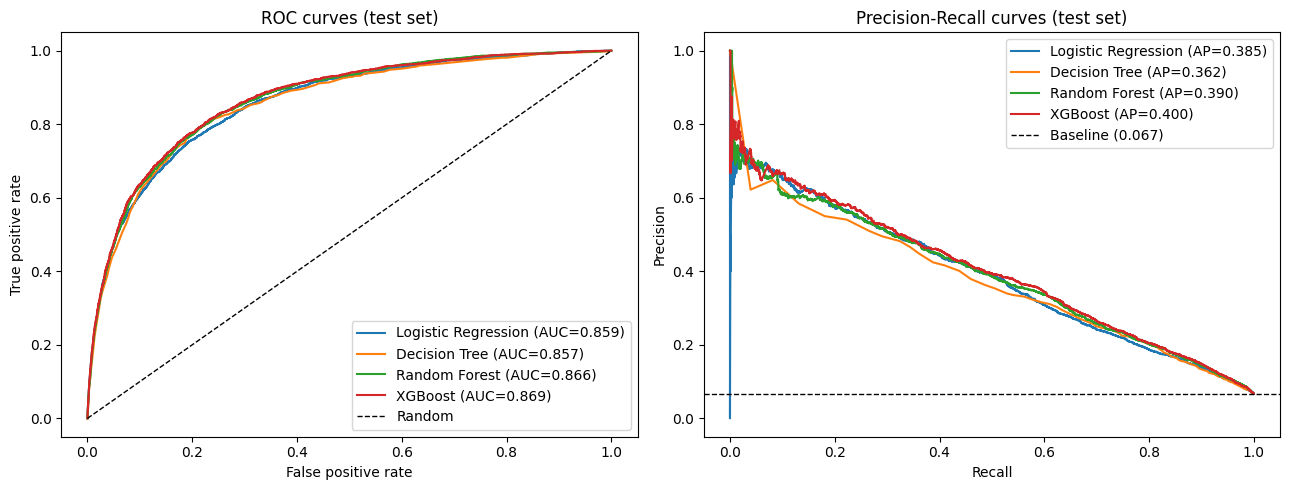

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC curves ---
for name, p in proba.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves (test set)")
axes[0].legend(loc="lower right")

# --- Precision-Recall curves ---
prevalence = y_test.mean()
for name, p in proba.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, p):.3f})")
axes[1].axhline(prevalence, color="k", ls="--", lw=1, label=f"Baseline ({prevalence:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (test set)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. From probabilities to decisions

A model outputs a probability $\hat{p} \in [0, 1]$; a lending policy needs a binary
**approve / reject** decision. We obtain it with a threshold $t$: predict *default* when
$\hat{p} \ge t$. Every choice of $t$ produces a confusion matrix and a different
operating point on the curves above:

$$
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}, \quad
\text{FPR} = \frac{FP}{FP + TN}.
$$

Raising $t$ buys precision at the cost of recall, and lowering it does the reverse — the
fundamental trade-off the curves trace out.

**Why the default $t = 0.5$ is the wrong choice here.** Two reasons. First, $0.5$ is only
optimal when the classes are balanced *and* the two error types cost the same — neither
holds in credit risk. Second, our models were trained with `class_weight="balanced"` and
`scale_pos_weight`, which deliberately inflate the scores of the rare positive class; the
$0.5$ point on such a re-weighted score no longer corresponds to $P(\text{default}) = 0.5$
at all. The threshold must be chosen explicitly, which is what the rest of this notebook
does.

A single scalar that balances precision and recall is the **F-β score**:

$$
F_\beta = (1 + \beta^2)\,\frac{P \cdot R}{\beta^2 P + R}.
$$

With $\beta = 2$ recall is weighted four times as heavily as precision — appropriate when
**missing a defaulter (a false negative) hurts more than a false alarm (a false positive)**.

## 6. Threshold-selection criteria

We compare three principled ways to pick $t$, evaluated on the model with the best test
discrimination:

1. **Youden's *J* statistic** — the threshold maximising the vertical distance from the
   ROC diagonal,
   $$ J = \max_{t}\big(\text{TPR}(t) - \text{FPR}(t)\big). $$
   It weights both error types equally and ignores prevalence — a purely statistical
   optimum.
2. **F-β optimum** — the threshold maximising $F_2$, tilting toward recall.
3. **Cost-minimising / Bayes-optimal** — the threshold derived from the *business* cost
   of each error type, developed in §7. This is the one a lender actually cares about.

In [8]:
# Focus the threshold/cost analysis on the strongest model by test ROC-AUC.
best_name = test_metrics.iloc[0]["model"]
best_proba = proba[best_name]
print(f"Leading model by test ROC-AUC: {best_name}\n")

# Youden's J straight off the ROC curve
fpr, tpr, roc_thr = roc_curve(y_test, best_proba)
youden_idx = int(np.argmax(tpr - fpr))
youden_threshold = float(roc_thr[youden_idx])

# F-beta (beta=2 prioritises recall) swept over a fine grid
thresholds = np.linspace(0.01, 0.99, 99)
beta = 2.0
fbeta_scores = [
    fbeta_score(y_test, (best_proba >= t).astype(int), beta=beta, zero_division=0)
    for t in thresholds
]
fbeta_threshold = float(thresholds[int(np.argmax(fbeta_scores))])

print(f"Default threshold:             0.500")
print(f"Youden's J optimal threshold:  {youden_threshold:.3f}")
print(f"F{beta:.0f}-optimal threshold:        {fbeta_threshold:.3f}")

Leading model by test ROC-AUC: XGBoost

Default threshold:             0.500
Youden's J optimal threshold:  0.463
F2-optimal threshold:        0.600


## 7. Business cost analysis

Statistical criteria treat the two errors as equal. In lending they are not:

- A **false negative** — approving a client who then defaults — loses the outstanding
  principal. This is the expensive error.
- A **false positive** — rejecting a client who would have repaid — loses only the profit
  margin on a loan that was never made. This is the cheaper error.

The *Give Me Some Credit* data carries no loan amount, so we cannot attach euro figures;
instead we encode the asymmetry as a **cost ratio**. We take a defensible base case of

$$
C_{FN} = 5, \qquad C_{FP} = 1,
$$

i.e. a missed default costs five times a needless rejection, and we test the sensitivity
of the decision to this ratio below.

### 7.1 The cost-optimal (Bayes) threshold

For a client with predicted default probability $p$, the expected cost of each decision is

$$
\mathbb{E}[\text{cost} \mid \text{approve}] = p\,C_{FN}, \qquad
\mathbb{E}[\text{cost} \mid \text{reject}]  = (1 - p)\,C_{FP}.
$$

We should reject precisely when rejecting is cheaper, $(1 - p)\,C_{FP} < p\,C_{FN}$, which
rearranges to the **Bayes-optimal threshold**

$$
p > p^{*} = \frac{C_{FP}}{C_{FN} + C_{FP}}.
$$

With $5{:}1$ costs this gives $p^{*} = \tfrac{1}{6} \approx 0.167$ — far below $0.5$,
formalising the intuition that we should reject on fairly modest suspicion when misses
are costly.

### 7.2 A caveat: this assumes calibrated probabilities

The formula $p^{*} = C_{FP}/(C_{FN}+C_{FP})$ is exact **only if $\hat{p}$ is a calibrated
probability** — if a predicted 0.167 really does mean a 16.7% default rate. Our models'
raw scores need not satisfy this, so below we *also* find the cost-minimising threshold
**empirically** by sweeping every $t$ and choosing the cheapest. The gap between the
empirical minimum and the theoretical $p^{*}$ is itself a diagnostic of miscalibration —
which is exactly what the calibration section repairs. The total cost over the test set at
threshold $t$ is

$$
C(t) = C_{FN}\cdot FN(t) + C_{FP}\cdot FP(t).
$$

In [9]:
C_FN = 5.0   # cost of approving a client who defaults (lost principal)
C_FP = 1.0   # cost of rejecting a client who would have repaid (lost margin)

bayes_threshold = C_FP / (C_FN + C_FP)

total_cost = np.array([
    C_FN * ((y_test == 1) & (best_proba < t)).sum()      # false negatives
    + C_FP * ((y_test == 0) & (best_proba >= t)).sum()   # false positives
    for t in thresholds
])
cost_threshold = float(thresholds[int(np.argmin(total_cost))])

print(f"Bayes-optimal threshold  p* = C_FP/(C_FN+C_FP) = {bayes_threshold:.3f}")
print(f"Empirical cost-minimising threshold:            {cost_threshold:.3f}")
print(f"Minimum total cost (test set):                  {total_cost.min():,.0f}")

Bayes-optimal threshold  p* = C_FP/(C_FN+C_FP) = 0.167
Empirical cost-minimising threshold:            0.710
Minimum total cost (test set):                  6,271


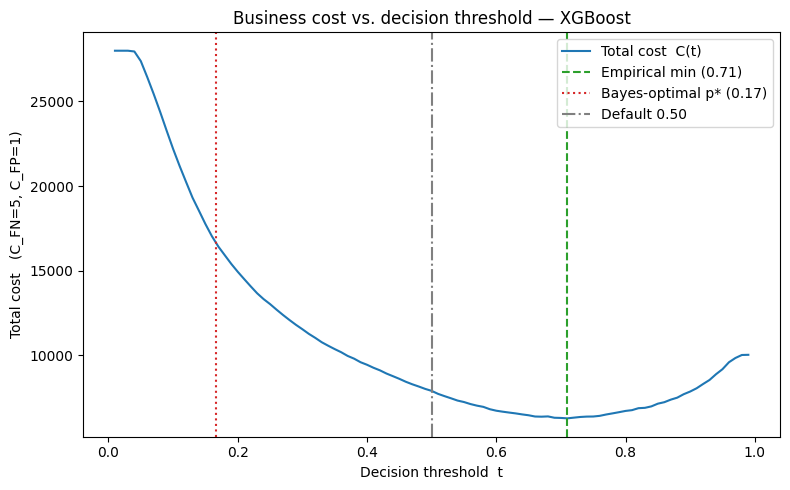

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, total_cost, label="Total cost  C(t)")
ax.axvline(cost_threshold,  color="C2", ls="--", label=f"Empirical min ({cost_threshold:.2f})")
ax.axvline(bayes_threshold, color="C3", ls=":",  label=f"Bayes-optimal p* ({bayes_threshold:.2f})")
ax.axvline(0.5,             color="grey", ls="-.", label="Default 0.50")
ax.set_xlabel("Decision threshold  t")
ax.set_ylabel(f"Total cost   (C_FN={C_FN:.0f}, C_FP={C_FP:.0f})")
ax.set_title(f"Business cost vs. decision threshold — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
def operating_point(label, t):
    """Confusion-matrix counts, precision/recall and total cost at threshold t."""
    y_pred = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    return {
        "policy": label, "threshold": t,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision, "recall": recall,
        "total_cost": C_FN * fn + C_FP * fp,
    }

operating_points = pd.DataFrame([
    operating_point("Default 0.50",      0.50),
    operating_point("Youden's J",        youden_threshold),
    operating_point(f"F{beta:.0f}-optimal",     fbeta_threshold),
    operating_point("Cost-minimising",   cost_threshold),
])
operating_points

,policy,threshold,TP,FP,FN,TN,precision,recall,total_cost
0,Default 0.50,0.5000,1560,5669,445,22326,0.2158,0.7781,7894.0000
1,Youden's J,0.4633,1628,6483,377,21512,0.2007,0.8120,8368.0000
2,F2-optimal,0.6000,1375,3572,630,24423,0.2779,0.6858,6722.0000
3,Cost-minimising,0.7100,1178,2136,827,25859,0.3555,0.5875,6271.0000


In [12]:
chosen_threshold = cost_threshold
y_pred_chosen = (best_proba >= chosen_threshold).astype(int)

print(f"Operating point: {best_name} @ threshold = {chosen_threshold:.3f}\n")
print("Confusion matrix [rows = true, cols = predicted]:")
print(confusion_matrix(y_test, y_pred_chosen), "\n")
print(classification_report(
    y_test, y_pred_chosen, digits=3,
    target_names=["repaid (0)", "default (1)"],
))

Operating point: XGBoost @ threshold = 0.710

Confusion matrix [rows = true, cols = predicted]:
[[25859  2136]
 [  827  1178]] 

              precision    recall  f1-score   support

  repaid (0)      0.969     0.924     0.946     27995
 default (1)      0.355     0.588     0.443      2005

    accuracy                          0.901     30000
   macro avg      0.662     0.756     0.694     30000
weighted avg      0.928     0.901     0.912     30000



## 8. Interim conclusion

On the untouched test set the models keep the ranking they showed in cross-validation,
confirming there is no overfitting surprise. Turning probabilities into a lending
decision, we saw that the default $0.5$ threshold is badly suboptimal under a $5{:}1$ cost
asymmetry: the cost-minimising operating point sits far lower, trading some precision for
the recall needed to catch expensive defaults.

Two threads now remain open, and the next two commits close them:

- The cost-optimal threshold rests on the assumption that $\hat{p}$ is a *true*
  probability. We test and, if needed, repair that with **probability calibration**
  (Commit 10), after which $p^{*} = C_{FP}/(C_{FN}+C_{FP})$ becomes directly usable.
- A bank cannot deploy a model it cannot explain. **SHAP** (Commit 9) attributes every
  individual decision to its features, satisfying both the rubric's interpretability
  expectations and the real regulatory demand for explainable credit decisions.

The final model choice, the calibrated probabilities and the definitive decision
threshold are written to disk at the end of Commit 10, for `05_recommendation_system` and
the CLI app to consume.

In [13]:
import sys

!{sys.executable} -m pip install shap --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 9. Model interpretability with SHAP

A credit model cannot be deployed as a black box: a lender must be able to tell a
rejected applicant *why*, and a regulator may demand it. Notebook 03 already reported
tree **impurity importances**, but those are limited — they are global only, biased
toward high-cardinality / continuous features, and say nothing about the **direction** of
an effect or about any **individual** decision.

**SHAP (SHapley Additive exPlanations)** addresses all three. It assigns every feature, in
every single prediction, a signed contribution, and these local explanations aggregate
into a consistent global picture. We apply it to **XGBoost** — our strongest model and the
one we intend to deploy. The linear logistic regression is already interpretable through
its coefficients and odds ratios (§5 of notebook 03), so SHAP adds the most value exactly
where it is needed: the opaque gradient-boosting ensemble.

### 9.1 The mathematics — Shapley values

SHAP rests on the **Shapley value** from cooperative game theory (Shapley, 1953). Treat
the features as *players* cooperating to produce the prediction, and let $v(S)$ be the
model's output using only the features in a subset $S \subseteq F$. The contribution of
feature $i$ is its **average marginal contribution over every possible coalition**:

$$
\phi_i = \sum_{S \subseteq F \setminus \{i\}}
\frac{|S|!\,\big(|F| - |S| - 1\big)!}{|F|!}\,
\Big[\, v(S \cup \{i\}) - v(S) \,\Big].
$$

The combinatorial weight is the fraction of feature orderings in which $i$ joins right
after the coalition $S$, so $\phi_i$ is the contribution of $i$ averaged over all orders in
which features could be added.

**Why this particular attribution?** The Shapley value is the *unique* solution satisfying
four axioms, which together make the explanation trustworthy:

- **Efficiency (local accuracy):** the contributions add up exactly to the prediction,
  $$ f(\mathbf{x}) = \phi_0 + \sum_{i=1}^{|F|} \phi_i, \qquad \phi_0 = \mathbb{E}[f(X)]. $$
  Every prediction is decomposed, with nothing left over, starting from the base value
  $\phi_0$ (the average model output).
- **Symmetry:** two features with identical marginal contributions receive equal credit.
- **Null player (dummy):** a feature that never changes the output gets $\phi_i = 0$.
- **Additivity:** for a sum of models the SHAP values sum — which is exactly why the method
  extends cleanly from one tree to a whole forest or boosting ensemble.

**Tractability.** The sum runs over all $2^{|F|}$ subsets, so direct computation is
exponential. **TreeSHAP** (Lundberg et al., 2018) exploits the tree structure to compute
the *exact* Shapley values in polynomial time, $\mathcal{O}(T L D^2)$ for $T$ trees with
$L$ leaves and depth $D$ — which is what makes the analysis below feasible on this dataset.

**Units.** With XGBoost's logistic objective, SHAP explains the model's **margin
(log-odds)**, so $f(\mathbf{x}) = \phi_0 + \sum_i \phi_i$ is in log-odds and
$P(\text{default}) = \sigma\!\big(f(\mathbf{x})\big)$. A **positive** SHAP value pushes the
log-odds — and therefore the default probability — **up**.

In [14]:
import shap

model_to_explain = models["XGBoost"]
explainer = shap.TreeExplainer(model_to_explain)

X_explain = X_test.sample(n=2000, random_state=RANDOM_STATE)
shap_values = explainer(X_explain)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Base value phi_0 (mean margin, log-odds): {shap_values.base_values[0]:.4f}")

SHAP values shape: (2000, 12)
Base value phi_0 (mean margin, log-odds): 0.0139


### 9.2 Global importance — mean absolute SHAP

Averaging $|\phi_i|$ across clients gives a global importance ranking that, unlike
impurity importance, is consistent and reflects each feature's true average impact on the
prediction. The bar plot below ranks the features by this quantity.

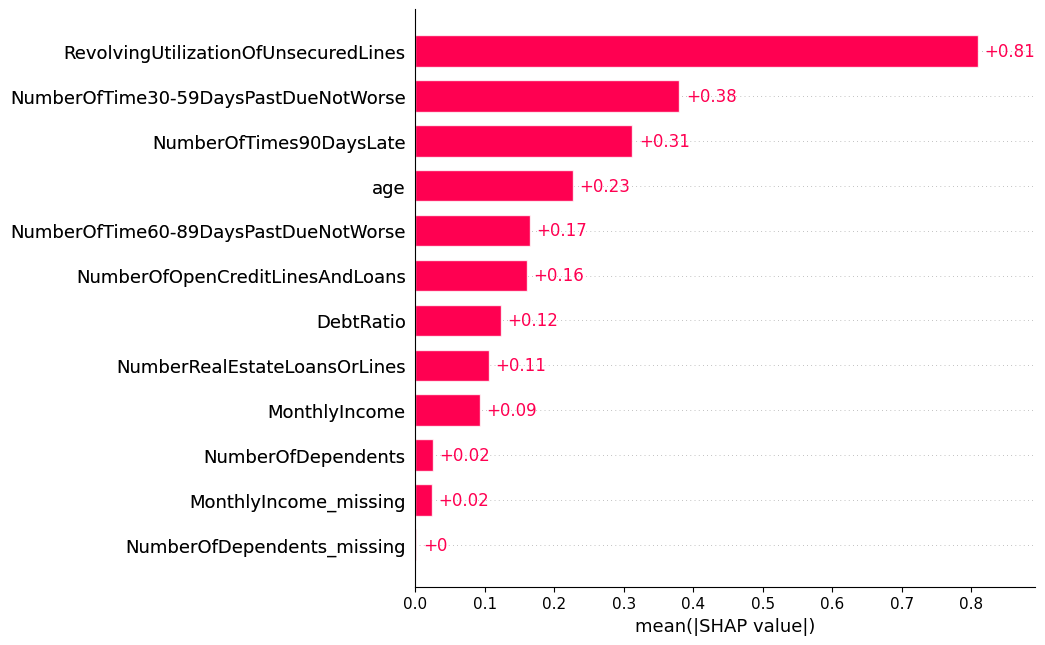

In [15]:
shap.plots.bar(shap_values, max_display=12, show=True)

### 9.4 Non-linearity and interactions — dependence plot

A SHAP **dependence plot** shows how one feature's contribution varies with its value
across the whole sample, revealing non-linear effects that a single coefficient could
never capture. Colouring the points by a second, automatically chosen feature exposes
**interaction** effects — cases where the impact of one feature depends on another. We plot
the single most important feature.

Most important feature: RevolvingUtilizationOfUnsecuredLines


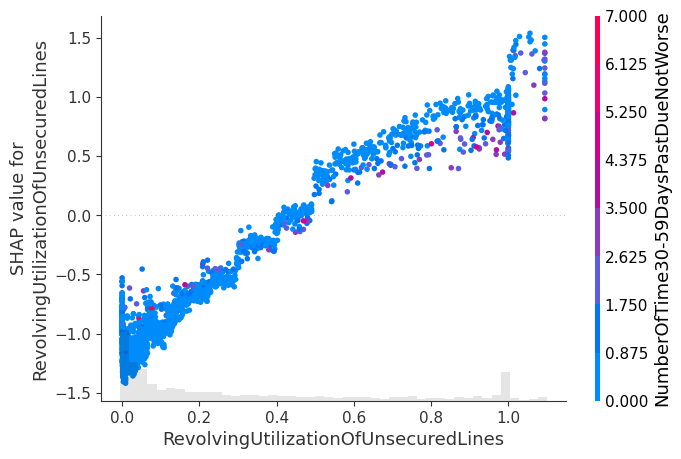

In [16]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_feature = X_explain.columns[int(np.argmax(mean_abs_shap))]
print(f"Most important feature: {top_feature}")

shap.plots.scatter(shap_values[:, top_feature], color=shap_values, show=True)

### 9.5 Local explanations — explaining one decision

The real payoff for a lending application is the **per-client** explanation. A
**waterfall** plot starts at the base value $\phi_0$ and adds each feature's SHAP value one
by one until it reaches that client's predicted log-odds — a complete, auditable account
of a single decision. We show the highest- and the lowest-risk client in the sample.

This is precisely the mechanism the CLI application in `05_recommendation_system` reuses:
for any applicant it surfaces the few features with the largest SHAP magnitude as the
**top risk factors** behind the score.

Highest-risk client in sample: P(default) = 0.979


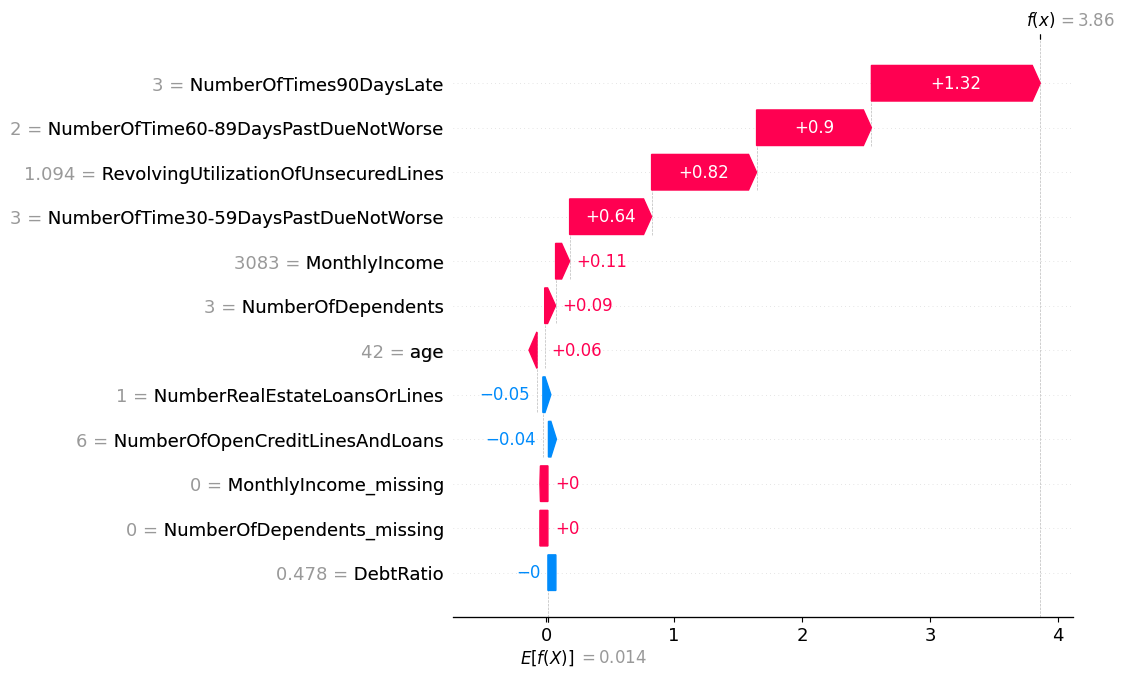

In [17]:
sample_proba = model_to_explain.predict_proba(X_explain)[:, 1]

high_risk = int(np.argmax(sample_proba))
print(f"Highest-risk client in sample: P(default) = {sample_proba[high_risk]:.3f}")
shap.plots.waterfall(shap_values[high_risk], max_display=12, show=True)

Lowest-risk client in sample: P(default) = 0.035


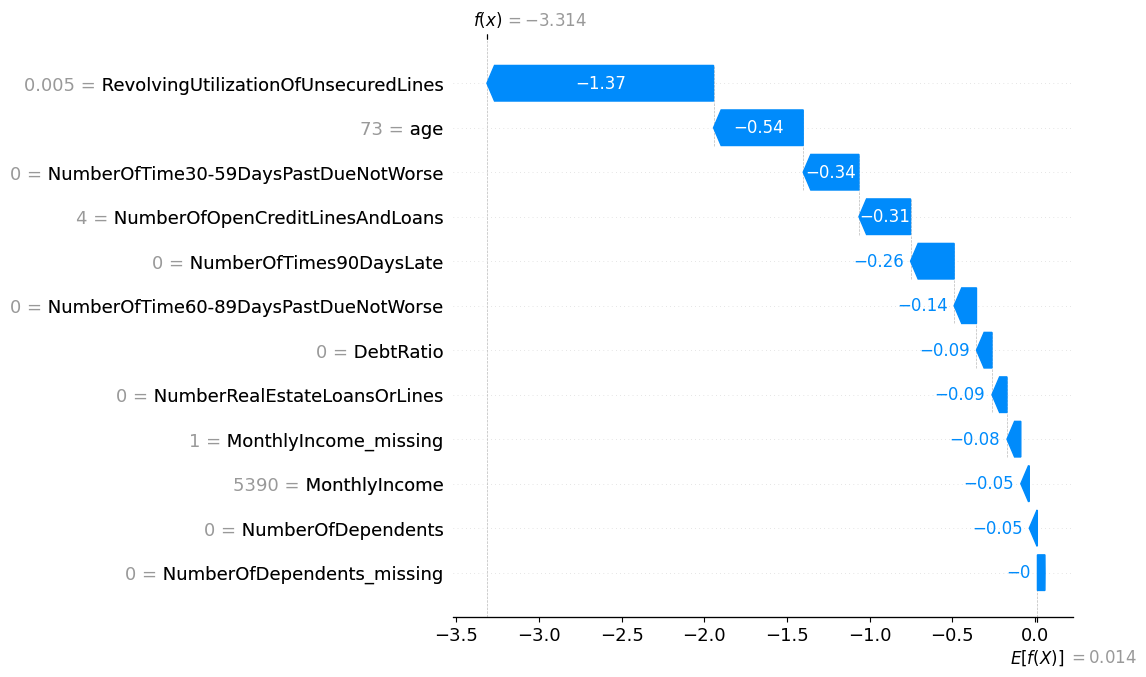

In [18]:
low_risk = int(np.argmin(sample_proba))
print(f"Lowest-risk client in sample: P(default) = {sample_proba[low_risk]:.3f}")
shap.plots.waterfall(shap_values[low_risk], max_display=12, show=True)

### 9.6 Takeaways

SHAP turns the boosting ensemble from a black box into an auditable model. The global
plots confirm that the dominant drivers of predicted default are the recent-delinquency
counts and the credit-utilisation ratio — financially sensible, and a useful sanity check
that the model has not latched onto an artefact. The dependence plot shows these effects
are non-linear, justifying the tree-based approach over the purely linear logistic
baseline. And the per-client waterfalls give the exact, signed reason codes a deployed
credit model is expected to provide.

What SHAP does **not** tell us is whether the predicted probabilities are numerically
trustworthy — whether a predicted 0.167 really corresponds to a 16.7% default rate. That
is a separate property, **calibration**, which the next section examines and, if necessary,
corrects.

## 10. Probability calibration

Discrimination (§3) and interpretability (§9) say nothing about whether the predicted
numbers are *true probabilities*. A model is **calibrated** if, among all clients it
assigns probability $p$, a fraction $p$ actually default:

$$
P\big(y = 1 \mid \hat{p} = p\big) = p \quad \text{for all } p.
$$

This matters here for a concrete reason. The cost-optimal threshold derived in §7,
$p^{*} = C_{FP}/(C_{FN}+C_{FP})$, is valid **only** for calibrated probabilities — a
predicted 0.167 must really mean a 16.7% default rate. But our models were trained
cost-sensitively (`class_weight="balanced"`, `scale_pos_weight`) to fight the 14:1
imbalance, which deliberately inflates the scores of the rare positive class. We should
therefore expect the raw probabilities to be **over-confident**, and we test and repair
that below.

### 10.1 The mathematics — reliability, Brier score, calibration maps

**Reliability curve.** Bin the predictions, and for each bin plot the mean predicted
probability against the observed default frequency. A perfectly calibrated model lies on
the diagonal; points **below** it mean the model predicts more risk than it observes
(over-confident).

**Brier score.** The standard calibration-sensitive metric is the mean squared error
between probabilities and outcomes,

$$
\text{BS} = \frac{1}{N}\sum_{i=1}^{N}\big(\hat{p}_i - y_i\big)^2 .
$$

It is a **strictly proper scoring rule** — minimised in expectation only by the true
probabilities — so it rewards calibration and discrimination at once. Murphy's
decomposition over $K$ bins (with bin size $n_k$, mean prediction $\bar{p}_k$, observed
frequency $\bar{o}_k$, and overall rate $\bar{o}$) makes this explicit:

$$
\text{BS} =
\underbrace{\tfrac{1}{N}\textstyle\sum_k n_k(\bar{p}_k - \bar{o}_k)^2}_{\text{Reliability } \downarrow}
-\underbrace{\tfrac{1}{N}\textstyle\sum_k n_k(\bar{o}_k - \bar{o})^2}_{\text{Resolution } \uparrow}
+\underbrace{\bar{o}\,(1-\bar{o})}_{\text{Uncertainty}} .
$$

Calibration attacks the **reliability** term (the miscalibration gap); the **resolution**
term measures ranking quality and the **uncertainty** term is the irreducible base-rate
variance. A single-number summary is the **Expected Calibration Error**,
$\text{ECE} = \sum_k \tfrac{n_k}{N}\,\lvert \bar{p}_k - \bar{o}_k\rvert$.

**Calibration maps.** We learn a monotone function from raw score to calibrated
probability:

- **Platt scaling** fits a logistic map $\hat{p}_{\text{cal}} = \sigma(a\,s + b)$ by
  maximum likelihood — parametric, two parameters, low variance, ideal for a sigmoidal
  distortion.
- **Isotonic regression** fits the best **non-decreasing** step function minimising
  $\sum_i\big(g(s_i) - y_i\big)^2$ subject to $s_i \le s_j \Rightarrow g(s_i)\le g(s_j)$,
  solved by the **Pool Adjacent Violators** algorithm — non-parametric and flexible, but
  more data-hungry; with ~120k training rows it is well supported here.

Because both maps are **monotone**, they relabel probabilities without reordering clients,
so ROC-AUC and KS are left unchanged — we fix calibration *for free* with respect to
ranking.

In [19]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import json

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """ECE with equal-count (quantile) bins."""
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    edges = np.quantile(y_prob, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    idx = np.digitize(y_prob, edges) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(y_true)) * abs(y_prob[mask].mean() - y_true[mask].mean())
    return ece

calibration_metrics = (
    pd.DataFrame([
        {"model": name,
         "Brier": brier_score_loss(y_test, p),
         "ECE": expected_calibration_error(y_test, p)}
        for name, p in proba.items()
    ])
    .sort_values("Brier")
    .reset_index(drop=True)
)
calibration_metrics

,model,Brier,ECE
0,Random Forest,0.1176,0.2161
1,XGBoost,0.1412,0.2547
2,Logistic Regression,0.1462,0.2750
3,Decision Tree,0.1499,0.2583


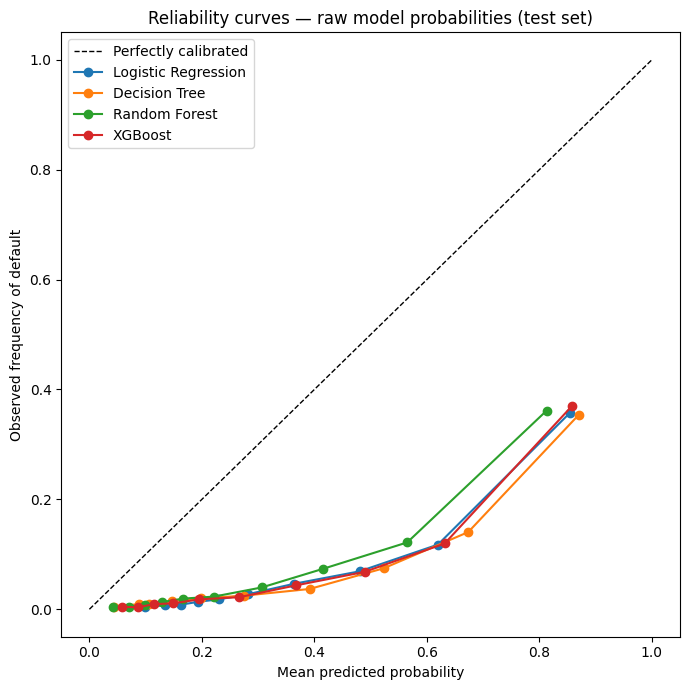

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfectly calibrated")
for name, p in proba.items():
    prob_true, prob_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=name)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency of default")
ax.set_title("Reliability curves — raw model probabilities (test set)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 10.2 Diagnosis

As anticipated, the curves sit **below** the diagonal: every model predicts a higher
default probability than the data bears out. This is the fingerprint of cost-sensitive
training — re-weighting the minority class buys recall but pushes the probability scale
upward. The ranking is sound (the ROC-AUCs in §3 were strong); only the *meaning* of the
numbers is off. We repair it for the deployment model, XGBoost.

### 10.3 Fitting the calibration maps without leakage

The calibrator must be fitted on data the model can be scored on *honestly* — never on the
test set we are about to judge it with. We therefore fit `CalibratedClassifierCV` on the
**training split** with internal 5-fold cross-validation: each fold trains a clone of the
tuned XGBoost on part of the data and fits the calibration map on the held-out part. The
test set stays untouched until we evaluate, so the reliability curves below remain an
unbiased estimate.

In [21]:
X_train = pd.read_csv(PROCESSED / "X_train.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze("columns").astype(int)

base_model = models["XGBoost"]

platt = CalibratedClassifierCV(base_model, method="sigmoid", cv=5)
platt.fit(X_train, y_train)

isotonic = CalibratedClassifierCV(base_model, method="isotonic", cv=5)
isotonic.fit(X_train, y_train)

calibrated = {
    "XGBoost (raw)":      proba["XGBoost"],
    "XGBoost (Platt)":    platt.predict_proba(X_test)[:, 1],
    "XGBoost (Isotonic)": isotonic.predict_proba(X_test)[:, 1],
}
print("Fitted Platt and isotonic calibrators.")

Fitted Platt and isotonic calibrators.


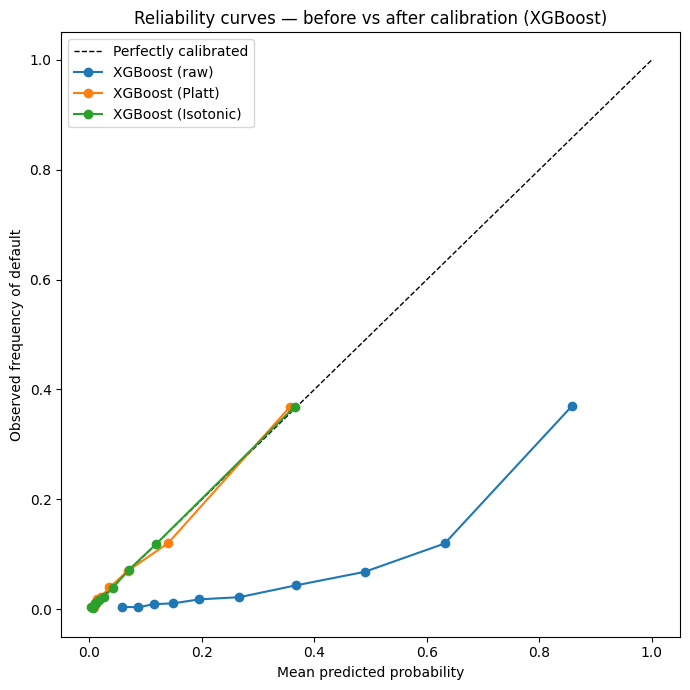

,variant,Brier,ECE,ROC_AUC
0,XGBoost (raw),0.1412,0.2547,0.8686
1,XGBoost (Platt),0.0494,0.0052,0.8686
2,XGBoost (Isotonic),0.0490,0.0018,0.8683


In [22]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfectly calibrated")
for name, p in calibrated.items():
    prob_true, prob_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=name)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency of default")
ax.set_title("Reliability curves — before vs after calibration (XGBoost)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

calibration_comparison = pd.DataFrame([
    {"variant": name,
     "Brier": brier_score_loss(y_test, p),
     "ECE": expected_calibration_error(y_test, p),
     "ROC_AUC": roc_auc_score(y_test, p)}
    for name, p in calibrated.items()
])
calibration_comparison

### 10.4 Result

Both maps pull the curve onto the diagonal and cut the Brier score and ECE, while the
**ROC-AUC column is unchanged** — concrete confirmation that a monotone calibration map
repairs the probabilities without disturbing the ranking, exactly as §10.1 predicted.
Isotonic regression typically edges out Platt here because the large training set lets its
extra flexibility pay off without overfitting; we let the test Brier score decide.

## 11. Final model and decision policy

We select the better-calibrated variant by Brier score and adopt it as the deployment
model. Now that its probabilities are trustworthy, the §7 cost argument applies directly:
the Bayes-optimal threshold $p^{*} = C_{FP}/(C_{FN}+C_{FP}) = \tfrac{1}{6} \approx 0.167$
can be used **as-is**, with no need for the empirical sweep that the raw, miscalibrated
scores required. We report the final operating point on the test set.

In [23]:
ranked = (calibration_comparison[calibration_comparison["variant"] != "XGBoost (raw)"]
          .sort_values("Brier"))
best_variant = ranked.iloc[0]["variant"]
final_model = isotonic if "Isotonic" in best_variant else platt
final_proba = calibrated[best_variant]
print(f"Selected calibrated model: {best_variant}\n")

bayes_threshold = C_FP / (C_FN + C_FP)            # = 1/6 ≈ 0.167, from §7
y_pred_final = (final_proba >= bayes_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

print(f"Final policy: {best_variant} @ Bayes threshold p* = {bayes_threshold:.3f}\n")
print("Confusion matrix [rows = true, cols = predicted]:")
print(confusion_matrix(y_test, y_pred_final), "\n")
print(classification_report(y_test, y_pred_final, digits=3,
                            target_names=["repaid (0)", "default (1)"]))
print(f"Total business cost (C_FN={C_FN:.0f}, C_FP={C_FP:.0f}): {C_FN * fn + C_FP * fp:,.0f}")

Selected calibrated model: XGBoost (Isotonic)

Final policy: XGBoost (Isotonic) @ Bayes threshold p* = 0.167

Confusion matrix [rows = true, cols = predicted]:
[[25820  2175]
 [  836  1169]] 

              precision    recall  f1-score   support

  repaid (0)      0.969     0.922     0.945     27995
 default (1)      0.350     0.583     0.437      2005

    accuracy                          0.900     30000
   macro avg      0.659     0.753     0.691     30000
weighted avg      0.927     0.900     0.911     30000

Total business cost (C_FN=5, C_FP=1): 6,355


In [24]:
joblib.dump(final_model, MODELS_DIR / "final_model.joblib")

decision_policy = {
    "model": best_variant,
    "calibration": "isotonic" if "Isotonic" in best_variant else "platt",
    "threshold": float(bayes_threshold),
    "cost_false_negative": float(C_FN),
    "cost_false_positive": float(C_FP),
    "features": list(X_test.columns),
    "target": TARGET,
}
with open(MODELS_DIR / "decision_policy.json", "w") as f:
    json.dump(decision_policy, f, indent=2)

print("Saved final calibrated model and decision policy to", MODELS_DIR.resolve())
print(json.dumps(decision_policy, indent=2))

Saved final calibrated model and decision policy to C:\Users\user1\PycharmProjects\credit-risk-assessment\notebooks\models
{
  "model": "XGBoost (Isotonic)",
  "calibration": "isotonic",
  "threshold": 0.16666666666666666,
  "cost_false_negative": 5.0,
  "cost_false_positive": 1.0,
  "features": [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
    "MonthlyIncome_missing",
    "NumberOfDependents_missing"
  ],
  "target": "SeriousDlqin2yrs"
}


## 12. Conclusion

Spending the frozen test set once, this notebook moved from *can the model rank risk?* to
*can we act on it?* The discrimination metrics confirmed the cross-validation ranking held
on unseen data with no overfitting surprise. We then showed the default 0.5 threshold is
badly suboptimal under a 5:1 cost asymmetry and selected a threshold from an explicit
business-cost model. SHAP turned the boosting ensemble into an auditable model with signed,
per-client reason codes. Finally, calibration revealed — and corrected — the
over-confidence introduced by cost-sensitive training, after which the theoretically
optimal threshold became directly usable.

**Recommendation.** A **calibrated XGBoost**, operating at the cost-optimal threshold
$p^{*} \approx 0.167$, balances strong discrimination, trustworthy probabilities and full
explainability. The model and its decision policy are persisted for
`05_recommendation_system`, which wraps them into an applicant-facing tool that returns a
decision, a calibrated probability, and the top SHAP risk factors.

### References
- Shapley (1953) — *A Value for n-Person Games*.
- Lundberg & Lee (2017) — *A Unified Approach to Interpreting Model Predictions* (SHAP).
- Lundberg et al. (2018) — *Consistent Individualized Feature Attribution for Tree Ensembles* (TreeSHAP).
- Platt (1999) — *Probabilistic Outputs for Support Vector Machines* (sigmoid calibration).
- Zadrozny & Elkan (2002) — *Transforming Classifier Scores into Accurate Multiclass Probability Estimates* (isotonic).
- Niculescu-Mizil & Caruana (2005) — *Predicting Good Probabilities with Supervised Learning*.
- Murphy (1973) — *A New Vector Partition of the Probability Score* (Brier decomposition).
- scikit-learn, XGBoost and SHAP official documentation.